# A-priori SAE Firing-Structure Router — recall-hole screens cluster-vs-latent reliability

This demo accompanies the experiment **"A-priori SAE firing-structure router"**.

**The problem.** A single sparse-autoencoder (SAE) latent is an unreliable unit of analysis: it suffers
from *feature absorption* (a broad "parent" latent silently drops sub-cases that get captured by other
latents). The full method builds a label-free **cluster-level unit** — a parent anchor plus
*firing-disjoint hole-covering absorbers* (the CCRG "K-track-lite" unit) — and asks **when** that
cluster unit beats the best single raw latent.

**The contribution shown here — the ROUTER.** From *one* cheap forward pass over the frozen
Gemma-Scope L12 / 16k JumpReLU SAE (`google/gemma-scope-2b-pt-res` over `unsloth/gemma-2-2b`), the
method reads two **label-free firing-structure signals** per concept:

* `recall_hole_max` — the fraction of concept-positives the broad parent latent *misses* (its biggest hole), and
* `jaccard_median` — the firing-Jaccard overlap between specialist detectors and the parent.

It then predicts the **regime** a-priori:

* **ABSORPTION** — the cluster unit will beat the best single raw latent, vs
* **CO-FIRING** — a single specialist already wins.

The **PRIMARY** rule is *recall-hole-alone*: `predict ABSORPTION iff parent recall-hole > tau_h`.

**What this notebook runs.** The heavy GPU step (encoding Gemma-2-2b through the SAE to *produce* the
firing-structure signals and the matched-pool downstream AUCs) is **not** rerun here — it needs a GPU
and multi-GB model downloads. Instead we load the **31 precomputed router-decision cards** (12
*derivation* concepts where the thresholds are fit + 19 truly-*prospective* concepts) and re-run the
**router decision logic verbatim** on CPU: threshold derivation by balanced-accuracy sweep,
leave-one-out, the frozen-rule predictions, and the decisive deliverable — the prospective hit-rate
**stratified by predicted regime** with Wilson 95% CIs. All of this is pure `numpy`; it reproduces the
published `tau`, balanced-accuracy and hit-rate numbers exactly.

In [1]:
# --- Dependencies (works on Colab AND in a clean local Jupyter) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# The router is pure numpy + matplotlib for the figure. Both are pre-installed on Colab, so they go
# behind the google.colab guard (installing them ON Colab would corrupt the pre-loaded C extensions);
# locally they are installed at Colab's exact versions so the environment matches.
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports (mirrors the STATS/ROUTER sections of method.py) ---
import json, os, math
import numpy as np
import matplotlib.pyplot as plt

# numpy 2.0 compat shims (harmless if already present)
if not hasattr(np, "alltrue"):  np.alltrue = np.all
if not hasattr(np, "product"):  np.product = np.prod

print("numpy", np.__version__)

numpy 2.0.2


In [3]:
# --- Data loading: GitHub raw URL first, local file as fallback (Colab-friendly) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-7ee30c-catching-silent-feature-absorption-in-fr/main/round-5/experiment-3/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
ref = data["metadata"]                       # published reference values, for cross-checking
cards = data["datasets"][0]["examples"]      # the 31 router-decision cards

print(f"loaded {len(cards)} router-decision cards from dataset '{data['datasets'][0]['dataset']}'")
print(f"  derivation concepts (thresholds fit here): "
      f"{sum(1 for c in cards if c['metadata_role']=='derivation')}")
print(f"  truly-prospective concepts (predict-then-measure): "
      f"{sum(1 for c in cards if c['metadata_role']=='prospective')}")
print(f"\nSAE: {ref['sae_release']}  {ref['sae_id']}")
print(f"model: {ref['model']}  | hook: {ref['hook']}  | firing: {ref['firing_convention']}")
print(f"recommended rule: {ref['recommended']}")

loaded 31 router-decision cards from dataset 'm6_router_concepts'
  derivation concepts (thresholds fit here): 12
  truly-prospective concepts (predict-then-measure): 19

SAE: google/gemma-scope-2b-pt-res  layer_12/width_16k/average_l0_82/params.npz
model: unsloth/gemma-2-2b  | hook: blocks.12.hook_resid_post  | firing: encode>0 (JumpReLU)
recommended rule: recall_hole_alone


## Configuration

The only tunable knobs of the router are the **threshold-sweep grid resolutions**. `method.py` derives
each rule by sweeping a `numpy.linspace` grid and keeping the threshold with the best balanced accuracy
(robustness-tie-broken by margin). The sweep is sub-second on CPU even at full resolution, so we use the
**original grids directly** — they comfortably fit the runtime budget and reproduce the published `tau`
values exactly.

The concept partition (which 12 concepts are *derivation* vs the 19 *prospective*) is a fixed registry,
not a tunable — it is reproduced here verbatim from `method.py`.

In [5]:
# ===== CONFIG (tunable: threshold-sweep grid resolution) =====
# These match method.py exactly. Lower the counts for a coarser/faster sweep; raise them for finer
# thresholds. Full resolution runs in <1s, so we keep the originals.
N_TAU_J = 34   # firing-Jaccard threshold sweep points     (method.py original: 34)
N_TAU_H = 40   # recall-hole     threshold sweep points     (method.py original: 40)
N_TAU   = 31   # legacy jaccard sweep points (compat)       (method.py original: 31)

TAU_J_GRID = np.linspace(0.02, 0.35, N_TAU_J)   # firing-Jaccard threshold sweep (router derivation)
TAU_H_GRID = np.linspace(0.0,  0.95, N_TAU_H)   # recall-hole threshold sweep (router derivation)
TAU_GRID   = np.linspace(0.05, 0.35, N_TAU)     # legacy jaccard sweep (kept for compatibility)

# ---- concept partition: DERIVATION (rule fit here) vs TRULY-PROSPECTIVE (verbatim from method.py) ----
DERIVATION = (["spelling_%s" % L for L in ["L", "O", "T", "I", "D"]]
              + ["numeric", "taxonomic"]
              + ["toxicity_%s" % s for s in ["threat", "identity_attack", "insult",
                                             "obscene", "sexual_explicit"]])
PROSPECTIVE_EXISTING = ["sentiment", "aspect_food", "aspect_service"]

def role_of(name):
    """Authoritative concept role: a concept is DERIVATION iff it is in the fixed DERIVATION registry."""
    return "derivation" if name in DERIVATION else "prospective"

print(f"derivation registry ({len(DERIVATION)}): {DERIVATION}")

derivation registry (12): ['spelling_L', 'spelling_O', 'spelling_T', 'spelling_I', 'spelling_D', 'numeric', 'taxonomic', 'toxicity_threat', 'toxicity_identity_attack', 'toxicity_insult', 'toxicity_obscene', 'toxicity_sexual_explicit']


## Parse the router cards into concept records

Each card carries the firing-structure signals the router reads (`jaccard_median`, `recall_hole_max`),
the ground-truth regime label (`= sign(auc_unit - auc_a)` — computed *after the fact* from the matched-pool
downstream AUCs; **the router never sees it at decision time**), and the precomputed downstream outcome
(`auc_unit` of the cluster unit, `auc_a` of the best single raw latent, the paired-bootstrap delta + CI)
which we keep only for the final table/figure.

In [6]:
def card_to_concept(e):
    """Map one stored card's metadata_* fields onto the keys the router functions expect."""
    return dict(
        concept=e["metadata_concept"],
        role=e["metadata_role"],
        granularity=e["metadata_granularity"],
        # --- label-free firing-structure signals (the ONLY inputs the router reads) ---
        jaccard_median=e["metadata_jaccard_median"],
        recall_hole_max=e["metadata_recall_hole_max"],
        # --- ground truth + outcome (measured on the GPU; not seen by the router at decision time) ---
        ground_truth_regime=e["metadata_ground_truth_regime"],            # sign(auc_unit - auc_a)
        ground_truth_regime_vs_h=e["metadata_ground_truth_regime_vs_h"],  # sign(auc_unit - auc_h)
        parent_latent=e["metadata_parent_latent"],
        parent_pos_firing=e["metadata_parent_pos_firing"],
        descriptive_only=(e["metadata_power_flag"] == "descriptive_only"),
        auc_unit=e["metadata_outcome_auc_unit"],
        auc_a=e["metadata_outcome_auc_a_rawlatent"],
        auc_h=e["metadata_outcome_auc_h_attribution"],
        delta=e["metadata_outcome_delta_vs_a"],
        delta_ci=e["metadata_outcome_delta_vs_a_ci"],
    )

concepts = [card_to_concept(e) for e in cards]
derivation  = [c for c in concepts if c["role"] == "derivation"]
prospective = [c for c in concepts if c["role"] == "prospective"]
print(f"{len(concepts)} concepts  |  {len(derivation)} derivation  |  {len(prospective)} prospective")

31 concepts  |  12 derivation  |  19 prospective


## Stats helpers (verbatim from `method.py`)

`balanced_accuracy` scores a regime prediction; `wilson_ci` gives an honest small-`n` 95% CI for a
hit-rate. Both are copied unchanged from the `STATS` section of `method.py`.

In [7]:
def balanced_accuracy(pred, truth):
    pred = np.asarray(pred); truth = np.asarray(truth)
    accs = []
    for cls in ["absorption", "co_firing"]:
        m = truth == cls
        if m.sum() == 0:
            continue
        accs.append((pred[m] == cls).mean())
    return float(np.mean(accs)) if accs else float("nan")


def wilson_ci(hits, n, z=1.959963984540054):
    """Wilson score 95% CI for a binomial proportion (hits/n). Honest for small n."""
    if n == 0:
        return dict(hits=0, n=0, rate=float("nan"), wilson_ci=[float("nan"), float("nan")])
    p = hits / n
    denom = 1.0 + z * z / n
    centre = (p + z * z / (2 * n)) / denom
    half = (z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n))) / denom
    return dict(hits=int(hits), n=int(n), rate=float(p),
                wilson_ci=[float(max(0.0, centre - half)), float(min(1.0, centre + half))])

## The router (verbatim from `method.py`)

These are the core decision functions, copied unchanged from the `ROUTER` section:

* `derive_single` — fit a single-signal threshold by balanced-accuracy sweep with a max-min-margin tie-break.
* `derive_combined` — fit the conjunction `(firing-Jaccard < tau_j) AND (recall-hole > tau_h)` (an ablation).
* `predict_recall_hole_alone` (PRIMARY), `predict_jaccard_alone`, `predict_combined` — the frozen-rule predictors.
* `loo_single` / `loo_combined` — leave-one-derivation-concept-out (refit on N-1, predict the held-out one).

In [8]:
def derive_single(concepts, key, lt, grid, truth_key="ground_truth_regime"):
    """Single-threshold router on `key` over an explicit `grid` (absorption iff value < tau when lt
    else value > tau). Tie-break = threshold most central in the optimal plateau (max min-margin)."""
    vals = np.array([c[key] for c in concepts], float)
    truth = np.array([c[truth_key] for c in concepts])
    if len(vals) == 0 or not np.isfinite(vals).any():
        return float("nan"), float("nan"), []
    sweep = []
    for tau in grid:
        pred = np.where(vals < tau if lt else vals > tau, "absorption", "co_firing")
        # margin: worst-case signed distance to threshold among correctly classified points
        margins = []
        for v, y in zip(vals, truth):
            pr = "absorption" if (v < tau if lt else v > tau) else "co_firing"
            d = (tau - v) if lt else (v - tau)              # >0 => predicted absorption
            margins.append((abs(d) if pr == y else -abs(d)))
        sweep.append(dict(tau=float(tau), balanced_acc=balanced_accuracy(pred, truth),
                          margin=float(min(margins)) if len(margins) else float("-inf")))
    best = max(sweep, key=lambda r: (r["balanced_acc"], r["margin"]))
    return best["tau"], best["balanced_acc"], sweep


def _jh_truth(concepts, truth_key="ground_truth_regime"):
    j = np.array([c["jaccard_median"] for c in concepts], float)
    h = np.array([c["recall_hole_max"] for c in concepts], float)
    truth = np.array([c[truth_key] for c in concepts])
    return j, h, truth


def _combined_margin(j, h, truth, tj, th):
    """Max-min separation margin for the AND-rule (tj, th): worst-case signed distance of a derivation
    concept to the decision boundary (positive iff correctly classified). Used as a robustness tie-break
    among threshold cells that share the best balanced-accuracy -> picks central, generalizable thresholds."""
    margins = []
    for ji, hi, yi in zip(j, h, truth):
        in_box = (ji < tj) and (hi > th)            # predicted absorption
        if yi == "absorption":
            # distance INTO the AND-box (must satisfy both); negative if outside
            m = min(tj - ji, hi - th)
        else:
            # co_firing correct iff OUTSIDE the box: safety = how clearly a constraint is violated
            m = max(ji - tj, th - hi)
        margins.append(m if (in_box == (yi == "absorption")) else -abs(m) - 1e-9)
    return float(min(margins)) if margins else float("-inf")


def derive_combined(concepts, tj_grid=TAU_J_GRID, th_grid=TAU_H_GRID, truth_key="ground_truth_regime"):
    """LEAD router: predict absorption iff (firing-Jaccard < tau_j) AND (recall_hole_max > tau_h).
    Fit (tau_j, tau_h) by maximizing balanced-accuracy on the DERIVATION concepts, with a max-min-margin
    tie-break for robustness. The conjunction is the recommendation because each single signal has a
    documented counterexample: jaccard-alone mislabels NUMERIC (high firing-Jaccard yet absorption) and
    can mislabel TAXONOMIC (low firing-Jaccard yet co_firing because the parent already has ~no holes);
    the recall-hole gate fixes taxonomic and the relaxed jaccard gate admits numeric."""
    j, h, truth = _jh_truth(concepts, truth_key)
    if len(j) == 0:
        return dict(tau_j=float("nan"), tau_h=float("nan"), balanced_acc=float("nan"),
                    margin=float("nan"), n_optimal_cells=0, degenerate_tau_h=None)
    best = None
    for tj in tj_grid:
        for th in th_grid:
            pred = np.where((j < tj) & (h > th), "absorption", "co_firing")
            ba = balanced_accuracy(pred, truth)
            mg = _combined_margin(j, h, truth, float(tj), float(th))
            cand = (ba, mg)
            if best is None or cand > (best["balanced_acc"], best["margin"]):
                best = dict(tau_j=float(tj), tau_h=float(th), balanced_acc=float(ba), margin=float(mg))
    n_opt = sum(1 for tj in tj_grid for th in th_grid
                if balanced_accuracy(np.where((j < tj) & (h > th), "absorption", "co_firing"), truth)
                >= best["balanced_acc"] - 1e-9)
    best["n_optimal_cells"] = int(n_opt)
    best["degenerate_tau_h"] = bool(best["tau_h"] <= th_grid[0] + 1e-9)
    return best


def predict_combined(c, tau_j, tau_h):
    return ("absorption" if (np.isfinite(tau_j) and np.isfinite(tau_h)
                             and c["jaccard_median"] < tau_j and c["recall_hole_max"] > tau_h)
            else "co_firing")


def predict_recall_hole_alone(c, tau_h_alone):
    """PRIMARY (M6b) recommendation: predict absorption iff parent recall-hole exceeds tau_h_alone."""
    return ("absorption" if (np.isfinite(tau_h_alone) and np.isfinite(c["recall_hole_max"])
                             and c["recall_hole_max"] > tau_h_alone) else "co_firing")


def predict_jaccard_alone(c, tau_j_alone):
    return ("absorption" if (np.isfinite(tau_j_alone) and np.isfinite(c["jaccard_median"])
                             and c["jaccard_median"] < tau_j_alone) else "co_firing")


def loo_single(concepts, key, lt, grid, truth_key="ground_truth_regime"):
    """Leave-one-derivation-concept-out for a single-signal rule (refit tau on N-1, predict held-out)."""
    rows = []
    for i, ci in enumerate(concepts):
        rest = [c for k, c in enumerate(concepts) if k != i]
        if len(set(c[truth_key] for c in rest)) < 2:
            tau, _, _ = derive_single(concepts, key, lt, grid, truth_key)     # degenerate fold -> global
        else:
            tau, _, _ = derive_single(rest, key, lt, grid, truth_key)
        v = float(ci[key])
        pred = "absorption" if (np.isfinite(tau) and (v < tau if lt else v > tau)) else "co_firing"
        rows.append(dict(concept=ci["concept"], tau_fold=float(tau), pred=pred,
                         ground_truth=ci[truth_key], hit=bool(pred == ci[truth_key])))
    acc = float(np.mean([r["hit"] for r in rows])) if rows else float("nan")
    return acc, rows


def loo_combined(concepts, tj_grid=TAU_J_GRID, th_grid=TAU_H_GRID, truth_key="ground_truth_regime"):
    """Leave-one-derivation-concept-out for the COMBINED rule (PRIMARY LOO)."""
    rows = []
    for i, ci in enumerate(concepts):
        rest = [c for k, c in enumerate(concepts) if k != i]
        if len(set(c[truth_key] for c in rest)) < 2:
            d = derive_combined(concepts, tj_grid, th_grid, truth_key)
        else:
            d = derive_combined(rest, tj_grid, th_grid, truth_key)
        pred = predict_combined(ci, d["tau_j"], d["tau_h"])
        rows.append(dict(concept=ci["concept"], tau_j_fold=d["tau_j"], tau_h_fold=d["tau_h"],
                         pred=pred, ground_truth=ci[truth_key], hit=bool(pred == ci[truth_key])))
    acc = float(np.mean([r["hit"] for r in rows])) if rows else float("nan")
    return acc, rows

## Freeze the rules on the 12 derivation concepts

This is the *fit* step: the PRIMARY recall-hole-alone threshold, the jaccard-alone ablation threshold,
and the combined-conjunction ablation are all derived **only** on the derivation concepts (their outcomes
were measured before the prospective ones — the predict-then-measure ordering). We also run leave-one-out
and cross-check every number against the values published in `method.py`'s output.

In [9]:
# PRIMARY: recall-hole-alone
tau_h_alone, bacc_halone, sweep_halone = derive_single(derivation, "recall_hole_max", False, TAU_H_GRID)
# ABLATION: jaccard-alone
tau_j_alone, bacc_jalone, sweep_jalone = derive_single(derivation, "jaccard_median", True, TAU_J_GRID)
# ABLATION: combined conjunction (jaccard AND recall-hole)
frozen = derive_combined(derivation)
tau_j, tau_h = frozen["tau_j"], frozen["tau_h"]

# Leave-one-derivation-concept-out
loo_h_acc, _ = loo_single(derivation, "recall_hole_max", False, TAU_H_GRID)
loo_j_acc, _ = loo_single(derivation, "jaccard_median", True, TAU_J_GRID)
loo_c_acc, _ = loo_combined(derivation)

print("===== FROZEN RULES (fit on the 12 derivation concepts) =====")
print(f"PRIMARY  recall-hole-alone : absorption iff recall_hole > {tau_h_alone:.4f}"
      f"   | balanced_acc={bacc_halone:.3f}  LOO={loo_h_acc:.3f}   <-- RECOMMENDED")
print(f"ABLATION jaccard-alone     : absorption iff jaccard    < {tau_j_alone:.4f}"
      f"   | balanced_acc={bacc_jalone:.3f}  LOO={loo_j_acc:.3f}")
print(f"ABLATION combined (AND)    : absorption iff jaccard<{tau_j:.4f} AND recall_hole>{tau_h:.4f}"
      f" | balanced_acc={frozen['balanced_acc']:.3f}  LOO={loo_c_acc:.3f}")
print(f"   (combined: n_optimal_cells={frozen['n_optimal_cells']}, degenerate_tau_h={frozen['degenerate_tau_h']})")

# ---- cross-check against the published method_out.json values ----
pr, cr, ssa = ref["primary_rule"], ref["combined_rule"], ref["single_signal_ablations"]
print("\n===== CROSS-CHECK vs published method.py output =====")
print(f"recall-hole tau   : recomputed {tau_h_alone:.10f}  published {pr['tau_h_alone']:.10f}  "
      f"match={abs(tau_h_alone - pr['tau_h_alone']) < 1e-9}")
print(f"recall-hole bacc  : recomputed {bacc_halone:.4f}      published {pr['balanced_acc']:.4f}      "
      f"match={abs(bacc_halone - pr['balanced_acc']) < 1e-9}")
print(f"jaccard tau       : recomputed {tau_j_alone:.4f}          published {ssa['jaccard_alone']['tau']:.4f}          "
      f"match={abs(tau_j_alone - ssa['jaccard_alone']['tau']) < 1e-9}")
print(f"combined (tj,th)  : recomputed ({tau_j:.4f},{tau_h:.4f})  published ({cr['tau_j']:.4f},{cr['tau_h']:.4f})  "
      f"match={abs(tau_j - cr['tau_j']) < 1e-9 and abs(tau_h - cr['tau_h']) < 1e-9}")

===== FROZEN RULES (fit on the 12 derivation concepts) =====
PRIMARY  recall-hole-alone : absorption iff recall_hole > 0.7795   | balanced_acc=1.000  LOO=0.833   <-- RECOMMENDED
ABLATION jaccard-alone     : absorption iff jaccard    < 0.0500   | balanced_acc=0.917  LOO=0.833
ABLATION combined (AND)    : absorption iff jaccard<0.3100 AND recall_hole>0.7795 | balanced_acc=1.000  LOO=0.833
   (combined: n_optimal_cells=7, degenerate_tau_h=False)

===== CROSS-CHECK vs published method.py output =====
recall-hole tau   : recomputed 0.7794871795  published 0.7794871795  match=True
recall-hole bacc  : recomputed 1.0000      published 1.0000      match=True
jaccard tau       : recomputed 0.0500          published 0.0500          match=True
combined (tj,th)  : recomputed (0.3100,0.7795)  published (0.3100,0.7795)  match=True


## Predict every concept and score the prospective set by predicted regime

With the rules frozen, we tag every concept with its three predictions (PRIMARY + 2 ablations) and the
`hit_vs_a` flag (did the predicted regime match the ground truth?). The **decisive deliverable** is the
prospective hit-rate **stratified by the PRIMARY predicted regime**, each with a Wilson 95% CI — the
measured error of a screening heuristic. Because the prospective set spans *both* regimes (new spelling
letters → absorption; professions / sentiment → co-firing), the router can be — and is — wrong in **both**
directions. The under-powered `descriptive_only` concept (`severe_toxicity`) is excluded from the
inferential strata, matching `method.py`.

In [10]:
# frozen-rule predictions for every concept (PRIMARY = recall-hole-alone; 2 ablations)
for c in concepts:
    c["predicted_regime"]          = predict_recall_hole_alone(c, tau_h_alone)   # PRIMARY
    c["predicted_regime_combined"] = predict_combined(c, tau_j, tau_h)           # ablation
    c["predicted_regime_jaccard"]  = predict_jaccard_alone(c, tau_j_alone)       # ablation
    c["hit_vs_a"]          = bool(c["predicted_regime"]          == c["ground_truth_regime"])
    c["hit_vs_a_combined"] = bool(c["predicted_regime_combined"] == c["ground_truth_regime"])
    c["hit_vs_a_jaccard"]  = bool(c["predicted_regime_jaccard"]  == c["ground_truth_regime"])

# prospective hit-rate STRATIFIED by predicted regime, with Wilson 95% CIs (inferential concepts only)
pro_inf = [c for c in prospective if not c["descriptive_only"]]
def strat(pred_key, hit_key):
    absn = [c for c in pro_inf if c[pred_key] == "absorption"]
    cof  = [c for c in pro_inf if c[pred_key] == "co_firing"]
    return dict(absorption_predicted=wilson_ci(sum(1 for c in absn if c[hit_key]), len(absn)),
                cofiring_predicted=wilson_ci(sum(1 for c in cof if c[hit_key]), len(cof)),
                combined_all=wilson_ci(sum(1 for c in pro_inf if c[hit_key]), len(pro_inf)))

prospective_hitrate_primary = strat("predicted_regime", "hit_vs_a")

def _fmt(w): return f"{w['hits']}/{w['n']} = {w['rate']:.3f}  Wilson95={np.round(w['wilson_ci'],3).tolist()}"
php = prospective_hitrate_primary
print(f"PROSPECTIVE hit-rate by PRIMARY predicted regime (inferential, n={len(pro_inf)}):")
print(f"  absorption_predicted : {_fmt(php['absorption_predicted'])}")
print(f"  cofiring_predicted   : {_fmt(php['cofiring_predicted'])}")
print(f"  combined_all         : {_fmt(php['combined_all'])}")

# cross-check vs published
rp = ref["prospective_hitrate_primary"]
ok = all(php[k]["hits"] == rp[k]["hits"] and php[k]["n"] == rp[k]["n"]
         for k in ["absorption_predicted", "cofiring_predicted", "combined_all"])
print(f"\ncross-check vs published prospective_hitrate_primary: match={ok}")
print(f"conjunction_beats_primary_out_of_sample (published) = "
      f"{ref['conjunction_beats_primary_out_of_sample']}  -> recall-hole-alone stays the recommendation")

PROSPECTIVE hit-rate by PRIMARY predicted regime (inferential, n=18):
  absorption_predicted : 3/6 = 0.500  Wilson95=[0.188, 0.812]
  cofiring_predicted   : 8/12 = 0.667  Wilson95=[0.391, 0.862]
  combined_all         : 11/18 = 0.611  Wilson95=[0.386, 0.797]

cross-check vs published prospective_hitrate_primary: match=True
conjunction_beats_primary_out_of_sample (published) = False  -> recall-hole-alone stays the recommendation


## Why recall-hole-alone, not firing-Jaccard-alone — the two honest counterexamples

`firing-Jaccard-alone` reaches only balanced-acc 0.917 because two derivation concepts break it; the
recall-hole signal routes both correctly. These are the load-bearing counterexamples reported in the paper.

In [11]:
dmap = {c["concept"]: c for c in derivation}
for name in ["numeric", "taxonomic"]:
    if name in dmap:
        r = dmap[name]
        ja = predict_jaccard_alone(r, tau_j_alone)
        rh = predict_recall_hole_alone(r, tau_h_alone)
        print(f"[{name}]  firing-Jaccard={r['jaccard_median']:.3f}  recall_hole={r['recall_hole_max']:.3f}"
              f"  parent_fires_on={r['parent_pos_firing']:.2f}")
        print(f"          ground_truth={r['ground_truth_regime']:<11}"
              f"jaccard-alone->{ja:<11}(MISLABELS)   recall-hole-alone->{rh:<11}(correct)\n")
for note in ref["counterexamples"]:
    print("•", note)

[numeric]  firing-Jaccard=0.285  recall_hole=0.800  parent_fires_on=0.55
          ground_truth=absorption jaccard-alone->co_firing  (MISLABELS)   recall-hole-alone->absorption (correct)

[taxonomic]  firing-Jaccard=0.058  recall_hole=0.763  parent_fires_on=0.95
          ground_truth=co_firing  jaccard-alone->co_firing  (MISLABELS)   recall-hole-alone->co_firing  (correct)

• numeric: firing-Jaccard=0.285 is HIGH yet ground-truth=absorption -> jaccard-alone (absorption iff low-J) MISLABELS it; the combined rule routes it correctly only via the relaxed jaccard gate + recall_hole=0.800>tau_h.
• taxonomic: firing-Jaccard=0.058 is LOW (narrow country specialists exist) yet ground-truth=co_firing: the parent already fires on 0.95 of positives (recall_hole_max=0.763) so there are no holes to fill -> the recall-hole gate correctly routes it co_firing where jaccard-alone would mislabel it absorption.


## Results & visualization

1. **Decision-plane scatter** — every concept in `(firing-Jaccard, recall-hole)` space, coloured by
   ground-truth regime, with the PRIMARY recall-hole threshold (horizontal line) and the jaccard-alone
   threshold (vertical line). The two counterexamples that motivate recall-hole over jaccard are annotated.
2. **Prospective hit-rate by predicted regime** with Wilson 95% CIs (the decisive deliverable).
3. A printed per-concept table mirroring `method.py`'s `_print_summary`.

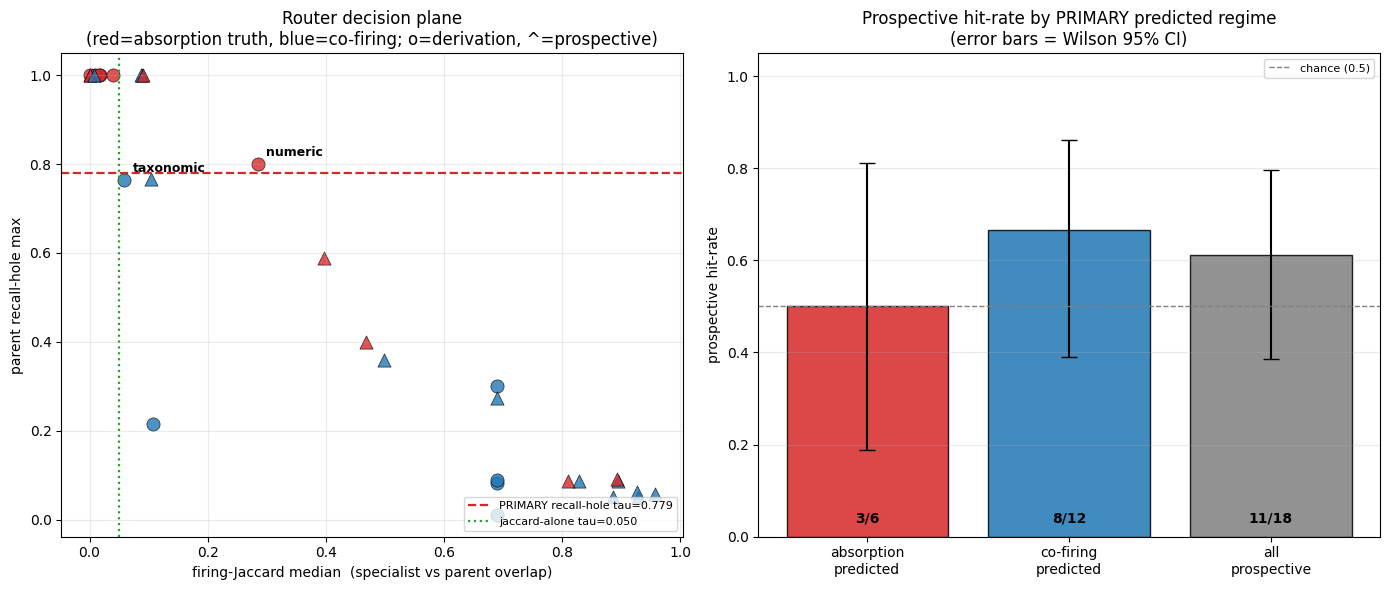


concept                   role         j_med   hole       pred      truth  aucU  aucA    dVa  hit
----------------------------------------------------------------------------------------------------
spelling_L                derivation   0.017  1.000 absorption absorption 0.855 0.848 +0.007 True
spelling_O                derivation   0.040  1.000 absorption absorption 0.683 0.633 +0.050 True
spelling_T                derivation   0.001  1.000 absorption absorption 0.695 0.667 +0.028 True
spelling_I                derivation   0.009  1.000 absorption absorption 0.595 0.548 +0.048 True
spelling_D                derivation   0.016  1.000 absorption absorption 0.716 0.711 +0.005 True
numeric                   derivation   0.285  0.800 absorption absorption 0.977 0.883 +0.094 True
taxonomic                 derivation   0.058  0.763  co_firing  co_firing 0.998 0.998 +0.000 True
toxicity_threat           derivation   0.689  0.301  co_firing  co_firing 0.571 0.622 -0.051 True
toxicity_identit

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# ---- (1) decision plane ----
col = {"absorption": "#d62728", "co_firing": "#1f77b4"}
mk  = {"derivation": "o", "prospective": "^"}
for c in concepts:
    ax1.scatter(c["jaccard_median"], c["recall_hole_max"], s=90, alpha=0.8,
                c=col[c["ground_truth_regime"]], marker=mk[c["role"]], edgecolors="k", linewidths=0.5)
ax1.axhline(tau_h_alone, color="#d62728", ls="--", lw=1.6,
            label=f"PRIMARY recall-hole tau={tau_h_alone:.3f}")
ax1.axvline(tau_j_alone, color="#2ca02c", ls=":", lw=1.6,
            label=f"jaccard-alone tau={tau_j_alone:.3f}")
for name in ["numeric", "taxonomic"]:
    if name in dmap:
        r = dmap[name]
        ax1.annotate(name, (r["jaccard_median"], r["recall_hole_max"]),
                     textcoords="offset points", xytext=(6, 6), fontsize=9, fontweight="bold")
ax1.set_xlabel("firing-Jaccard median  (specialist vs parent overlap)")
ax1.set_ylabel("parent recall-hole max")
ax1.set_title("Router decision plane\n(red=absorption truth, blue=co-firing; o=derivation, ^=prospective)")
ax1.legend(loc="lower right", fontsize=8)
ax1.grid(alpha=0.25)

# ---- (2) prospective hit-rate by predicted regime + Wilson CIs ----
labels = ["absorption\npredicted", "co-firing\npredicted", "all\nprospective"]
keys   = ["absorption_predicted", "cofiring_predicted", "combined_all"]
rates  = [php[k]["rate"] for k in keys]
los    = [php[k]["rate"] - php[k]["wilson_ci"][0] for k in keys]
his    = [php[k]["wilson_ci"][1] - php[k]["rate"] for k in keys]
ns     = [php[k]["n"] for k in keys]
bars = ax2.bar(labels, rates, yerr=[los, his], capsize=6,
               color=["#d62728", "#1f77b4", "#7f7f7f"], alpha=0.85, edgecolor="k")
ax2.axhline(0.5, color="gray", ls="--", lw=1, label="chance (0.5)")
for b, k, n in zip(bars, keys, ns):
    ax2.text(b.get_x() + b.get_width()/2, 0.03,
             f"{php[k]['hits']}/{n}", ha="center", fontsize=10, fontweight="bold")
ax2.set_ylim(0, 1.05)
ax2.set_ylabel("prospective hit-rate")
ax2.set_title("Prospective hit-rate by PRIMARY predicted regime\n(error bars = Wilson 95% CI)")
ax2.legend(loc="upper right", fontsize=8)
ax2.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

# ---- (3) per-concept table (mirrors method.py _print_summary) ----
print(f"\n{'concept':<26}{'role':<11}{'j_med':>7}{'hole':>7}{'pred':>11}{'truth':>11}"
      f"{'aucU':>6}{'aucA':>6}{'dVa':>7}{'hit':>5}")
print("-" * 100)
for c in concepts:
    print(f"{c['concept']:<26}{c['role']:<11}{c['jaccard_median']:>7.3f}{c['recall_hole_max']:>7.3f}"
          f"{c['predicted_regime']:>11}{c['ground_truth_regime']:>11}"
          f"{c['auc_unit']:>6.3f}{c['auc_a']:>6.3f}{c['delta']:>+7.3f}{str(c['hit_vs_a']):>5}")